# 02 · Análisis exploratorio (EDA)

**Proyecto:** Olist, marketplace brasileño de e-commerce · **Datos:** `data/df_EDA.csv`, generado por [`01_preparacion_datos.ipynb`](01_preparacion_datos.ipynb)

Este notebook responde cinco preguntas de negocio antes de construir el dashboard:

1. ¿Cómo evolucionan las ventas y qué tan concentradas están (categorías, estados, vendedores)?
2. ¿Cuánto gasta un cliente por pedido y cómo paga?
3. ¿Dónde se generan los retrasos de entrega?
4. ¿Cuánto pesan los retrasos en la satisfacción?
5. ¿Los clientes vuelven a comprar?

> **Regla de este notebook:** cada métrica se calcula en su granularidad correcta (pedido, ítem o pago).
> La sección 1 explica por qué: el archivo plano repite filas y, si se suma directo, **infla las ventas un 28%**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from olist_utils import (
    cargar_eda, nivel_pedido, nivel_item, nivel_pago, nivel_cliente,
    estilo, tabla, fmt_miles, fmt_pct, barras_h, pie_de_fuente,
    AZUL, NARANJA, VERDE, OCRE, VIOLETA, GRIS, TINTA_2, MAL, BIEN,
)

estilo()
df = cargar_eda()
print(f"{len(df):,} filas × {df.shape[1]} columnas")

114,630 filas × 58 columnas


## 1. Granularidad: por qué no se puede sumar el archivo plano

`df_EDA.csv` une pedidos, ítems y pagos en una sola tabla. Un pedido con 2 ítems pagado en 3 cuotas-voucher aparece en **2 × 3 = 6 filas**,
y cada fila repite el valor del pago. Por eso se separa en tres tablas antes de calcular cualquier cosa.

In [2]:
pedidos = nivel_pedido(df)
items = nivel_item(df)
pagos = nivel_pago(df)
clientes = nivel_cliente(pedidos)

granos = pd.DataFrame({
    "filas": [len(df), len(pedidos), len(items), len(pagos), len(clientes)],
}, index=["archivo plano", "pedidos", "ítems", "pagos", "clientes"])
granos

,filas
archivo plano,114630
pedidos,96124
ítems,109796
pagos,100396
clientes,93011


In [3]:
suma_plana = df["payment_value"].sum()
suma_real = pagos["payment_value"].sum()
comparacion = pd.DataFrame({
    "sumando el archivo plano": [suma_plana, df["payment_value"].sum() / df["order_id"].nunique(), df["price"].sum()],
    "en su granularidad": [suma_real, pedidos["precio_ticket"].mean(), items["price"].sum()],
}, index=["facturación total (R$)", "ticket medio (R$)", "venta de productos (R$)"])
comparacion["inflado"] = comparacion.iloc[:, 0] / comparacion.iloc[:, 1] - 1
tabla(comparacion, {"sumando el archivo plano": "{:,.0f}", "en su granularidad": "{:,.0f}", "inflado": "{:+.1%}"})

,sumando el archivo plano,en su granularidad,inflado
facturación total (R$),"19,727,239","15,382,151",+28.2%
ticket medio (R$),205,160,+28.2%
venta de productos (R$),"13,773,205","13,181,316",+4.5%


**Qué incluye el dataset.** Son los pedidos con todas sus fechas registradas (compra → aprobación → despacho → entrega),
que en la práctica son los entregados, más 6 cancelados que llegaron a entregarse. Los pedidos en curso, cancelados antes del envío
o sin fecha de entrega (≈3%) quedaron fuera en la preparación. El análisis describe, por lo tanto, **el negocio que efectivamente se entregó**.

In [4]:
print("Pedidos por estado:", pedidos["order_status"].value_counts().to_dict())
print("Período:", pedidos["order_purchase_timestamp"].min().date(), "→", pedidos["order_purchase_timestamp"].max().date())

Pedidos por estado: {'delivered': 96118, 'canceled': 6}
Período: 2016-10-03 → 2018-08-29


## 2. Evolución de las ventas

Se usa el período **enero 2017 – agosto 2018**: 2016 tiene solo 271 pedidos (la plataforma estaba arrancando) y no es comparable.
Pedidos y facturación van en gráficos separados para no mezclar escalas en un doble eje.

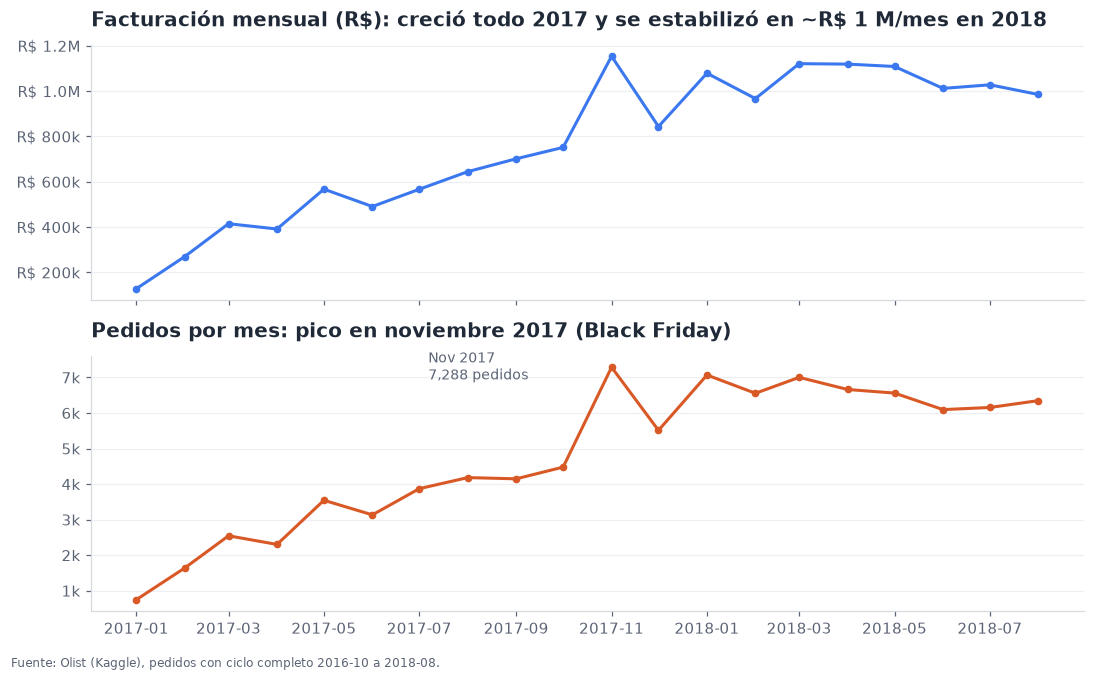

In [5]:
pedidos["mes"] = pedidos["order_purchase_timestamp"].dt.to_period("M")
mensual = (
    pedidos[pedidos["mes"] >= "2017-01"]
    .groupby("mes")
    .agg(pedidos=("order_id", "nunique"), facturacion=("precio_ticket", "sum"), ticket=("precio_ticket", "mean"))
)
x = mensual.index.to_timestamp()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.plot(x, mensual["facturacion"], color=AZUL, lw=2, marker="o", ms=4)
ax1.set_title("Facturación mensual (R$): creció todo 2017 y se estabilizó en ~R$ 1 M/mes en 2018")
fmt_miles(ax1, prefijo="R$ ")
ax2.plot(x, mensual["pedidos"], color=NARANJA, lw=2, marker="o", ms=4)
ax2.set_title("Pedidos por mes: pico en noviembre 2017 (Black Friday)")
fmt_miles(ax2)
pico = mensual["pedidos"].idxmax()
ax2.annotate(f"{pico.strftime('%b %Y')}\n{mensual.loc[pico, 'pedidos']:,} pedidos", (pico.to_timestamp(), mensual.loc[pico, "pedidos"]),
             xytext=(-120, -8), textcoords="offset points", fontsize=9, color=TINTA_2)
fig.tight_layout()
pie_de_fuente(fig)
plt.show()

In [6]:
ene_ago = lambda anio: mensual[(mensual.index.year == anio) & (mensual.index.month <= 8)]
comp = pd.DataFrame({a: ene_ago(a)[["pedidos", "facturacion"]].sum() for a in (2017, 2018)})
comp.loc["ticket medio"] = comp.loc["facturacion"] / comp.loc["pedidos"]
comp["variación"] = comp[2018] / comp[2017] - 1
tabla(comp, {2017: "{:,.0f}", 2018: "{:,.0f}", "variación": "{:+.1%}"})

,2017,2018,variación
pedidos,"21,973","52,452",+138.7%
facturacion,"3,469,794","8,416,358",+142.6%
ticket medio,158,160,+1.6%


**Estacionalidad.** El promedio por mes del año mezcla años incompletos (septiembre–diciembre solo existen en 2017),
así que se compara el **patrón semanal y horario**, que sí tiene muestra completa.

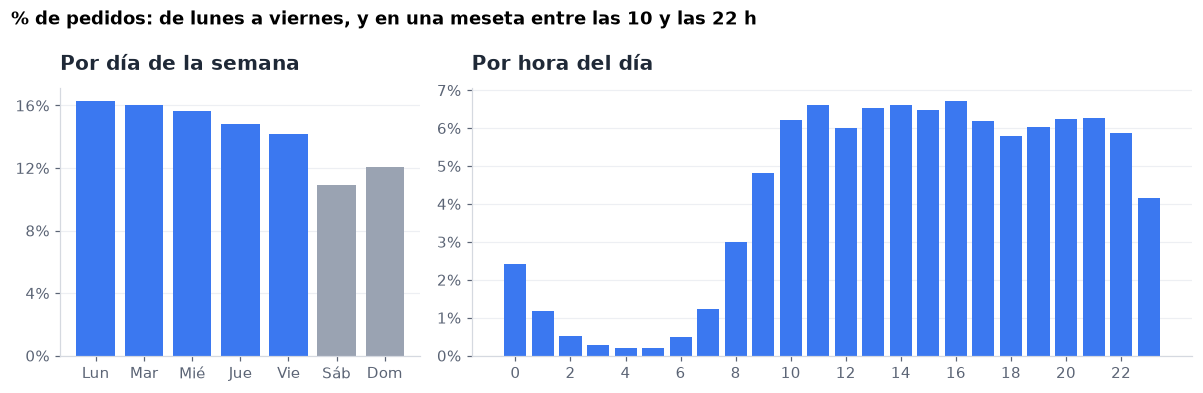

In [7]:
orden_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
nombres_dias = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
por_dia = pedidos["day_of_week"].value_counts().reindex(orden_dias)
por_hora = pedidos["hour"].value_counts().sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [1, 2]})
ax1.bar(nombres_dias, por_dia.values / por_dia.sum(), color=[AZUL] * 5 + [GRIS] * 2)
ax1.set_title("Por día de la semana")
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.04))
fmt_pct(ax1)
ax2.bar(por_hora.index, por_hora.values / por_hora.sum(), color=AZUL)
ax2.set_title("Por hora del día")
ax2.set_xticks(range(0, 24, 2))
fmt_pct(ax2, decimales=0)
fig.suptitle("% de pedidos: de lunes a viernes, y en una meseta entre las 10 y las 22 h", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
plt.show()

## 3. Ticket y medios de pago

El ticket es el **total pagado por pedido** (productos + envío). Se calcula sobre 96 mil pedidos, no sobre filas.

Ticket medio R$ 160 · mediana R$ 105 · p90 R$ 307 · máx R$ 13,664


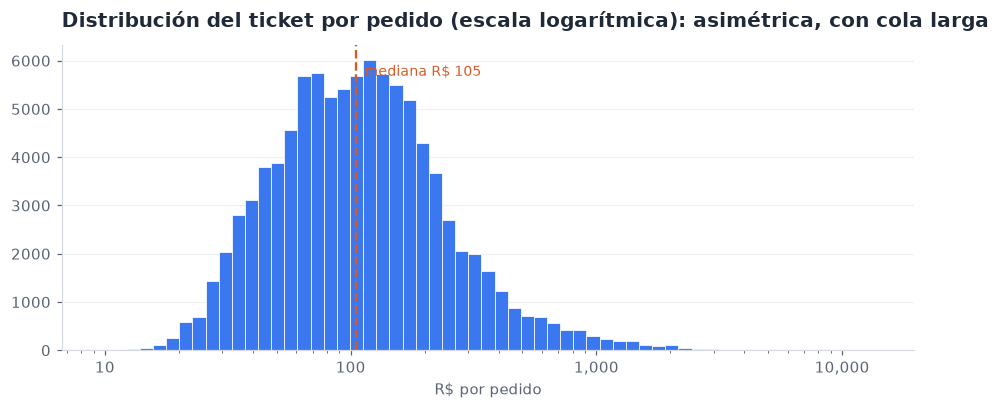

In [8]:
t = pedidos["precio_ticket"]
print(f"Ticket medio R$ {t.mean():,.0f} · mediana R$ {t.median():,.0f} · p90 R$ {t.quantile(.9):,.0f} · máx R$ {t.max():,.0f}")

fig, ax = plt.subplots(figsize=(10, 3.6))
bins = np.logspace(np.log10(t.min()), np.log10(t.max()), 60)
ax.hist(t, bins=bins, color=AZUL, edgecolor="white", linewidth=0.5)
ax.set_xscale("log")
ax.axvline(t.median(), color=NARANJA, ls="--", lw=1.5)
ax.text(t.median() * 1.08, ax.get_ylim()[1] * 0.9, f"mediana R$ {t.median():,.0f}", color=NARANJA, fontsize=9)
ax.set_title("Distribución del ticket por pedido (escala logarítmica): asimétrica, con cola larga")
ax.set_xlabel("R$ por pedido")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
plt.show()

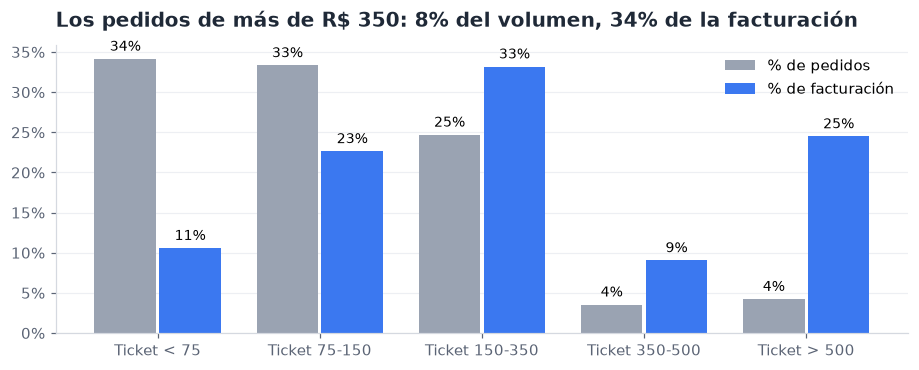

In [9]:
orden_rangos = ["Ticket < 75", "Ticket 75-150", "Ticket 150-350", "Ticket 350-500", "Ticket > 500"]
rangos = pedidos.groupby("rango_ticket").agg(pedidos=("order_id", "size"), facturacion=("precio_ticket", "sum")).reindex(orden_rangos)
rangos_pct = rangos / rangos.sum()

fig, ax = plt.subplots(figsize=(10, 3.4))
posiciones = np.arange(len(orden_rangos))
ax.bar(posiciones - 0.2, rangos_pct["pedidos"], width=0.38, color=GRIS, label="% de pedidos")
ax.bar(posiciones + 0.2, rangos_pct["facturacion"], width=0.38, color=AZUL, label="% de facturación")
for i, (p, f) in enumerate(rangos_pct.values):
    ax.text(i - 0.2, p + 0.01, f"{p:.0%}", ha="center", fontsize=9)
    ax.text(i + 0.2, f + 0.01, f"{f:.0%}", ha="center", fontsize=9)
ax.set_xticks(posiciones, orden_rangos)
fmt_pct(ax)
ax.legend(loc="upper right")
ax.set_title("Los pedidos de más de R$ 350: 8% del volumen, 34% de la facturación")
plt.show()

In [10]:
etiquetas_pago = {"credit_card": "Tarjeta de crédito", "boleto": "Boleto bancario", "voucher": "Voucher", "debit_card": "Tarjeta de débito"}
medios = pagos.assign(medio=pagos["payment_type"].map(etiquetas_pago)).groupby("medio").agg(
    pagos=("order_id", "size"), valor=("payment_value", "sum"))
medios_pct = (medios / medios.sum()).sort_values("valor", ascending=False)
tabla(medios_pct, "{:.1%}")

,pagos,valor
medio,,
Tarjeta de crédito,74.0%,78.5%
Boleto bancario,19.0%,18.0%
Voucher,5.5%,2.2%
Tarjeta de débito,1.5%,1.3%


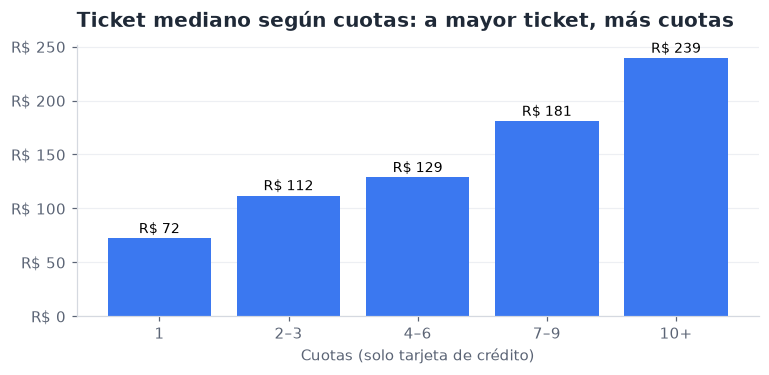

,pagos,ticket_mediano,% de pagos con tarjeta
cuotas,,,
1,"24,677",R$ 72,33%
2–3,"22,161",R$ 112,30%
4–6,"15,713",R$ 129,21%
7–9,"6,296",R$ 181,8%
10+,"5,470",R$ 239,7%


In [11]:
cuotas = pagos[pagos["payment_type"] == "credit_card"].merge(pedidos[["order_id", "precio_ticket"]], on="order_id")
cuotas["cuotas"] = pd.cut(cuotas["payment_installments"], [0, 1, 3, 6, 9, 24], labels=["1", "2–3", "4–6", "7–9", "10+"])
resumen_cuotas = cuotas.groupby("cuotas", observed=True).agg(pagos=("order_id", "size"), ticket_mediano=("precio_ticket", "median"))
resumen_cuotas["% de pagos con tarjeta"] = resumen_cuotas["pagos"] / resumen_cuotas["pagos"].sum()

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(resumen_cuotas.index.astype(str), resumen_cuotas["ticket_mediano"], color=AZUL)
for i, v in enumerate(resumen_cuotas["ticket_mediano"]):
    ax.text(i, v + 5, f"R$ {v:,.0f}", ha="center", fontsize=9)
ax.set_title("Ticket mediano según cuotas: a mayor ticket, más cuotas")
ax.set_xlabel("Cuotas (solo tarjeta de crédito)")
fmt_miles(ax, prefijo="R$ ")
plt.show()
tabla(resumen_cuotas, {"pagos": "{:,.0f}", "ticket_mediano": "R$ {:,.0f}", "% de pagos con tarjeta": "{:.0%}"})

## 4. Categorías: dónde está la venta

Las ventas por categoría se calculan con el **precio de cada ítem** (los pagos no se pueden repartir por categoría).
Las categorías originales se tradujeron al español y se agruparon en 64 categorías y 10 macro-categorías.

18 de 64 categorías generan el 80% de la venta de productos.


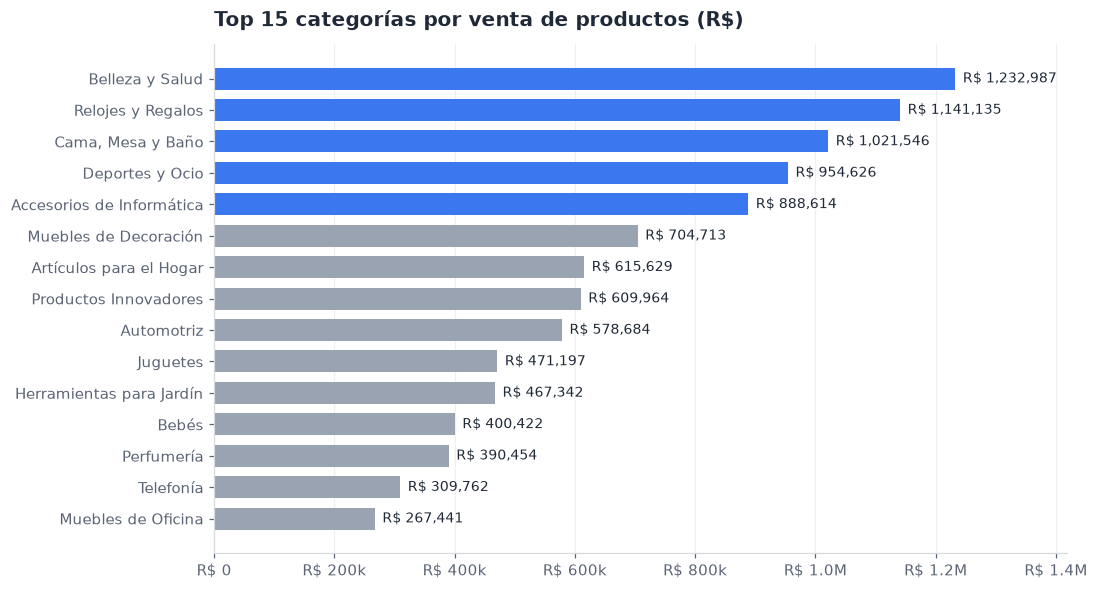

In [12]:
por_categoria = items.groupby("product_category_name_es").agg(
    venta=("price", "sum"), items=("order_item_id", "size"), pedidos=("order_id", "nunique"), precio_medio=("price", "mean")
).sort_values("venta", ascending=False)
por_categoria["% venta"] = por_categoria["venta"] / por_categoria["venta"].sum()
por_categoria["% acumulado"] = por_categoria["% venta"].cumsum()

n80 = (por_categoria["% acumulado"] < 0.8).sum() + 1
print(f"{n80} de {len(por_categoria)} categorías generan el 80% de la venta de productos.")

barras_h(por_categoria["venta"].head(15), "Top 15 categorías por venta de productos (R$)", fmt="R$ {:,.0f}", resaltar=5)
fmt_miles(plt.gca(), eje="x", prefijo="R$ ")
plt.show()

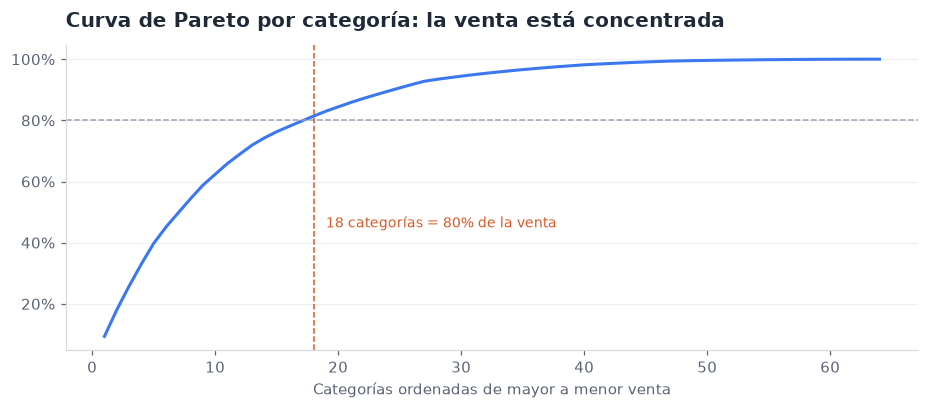

In [13]:
fig, ax = plt.subplots(figsize=(10, 3.6))
curva = por_categoria["% acumulado"].values
ax.plot(np.arange(1, len(curva) + 1), curva, color=AZUL, lw=2)
ax.axhline(0.8, color=GRIS, ls="--", lw=1)
ax.axvline(n80, color=NARANJA, ls="--", lw=1)
ax.text(n80 + 1, 0.45, f"{n80} categorías = 80% de la venta", color=NARANJA, fontsize=9)
ax.set_title("Curva de Pareto por categoría: la venta está concentrada")
ax.set_xlabel("Categorías ordenadas de mayor a menor venta")
fmt_pct(ax)
plt.show()

In [14]:
por_macro = items.groupby("macro_category").agg(venta=("price", "sum"), precio_medio=("price", "mean"), items=("price", "size"))
por_macro["% venta"] = por_macro["venta"] / por_macro["venta"].sum()
tabla(por_macro.sort_values("venta", ascending=False), 
    {"venta": "R$ {:,.0f}", "precio_medio": "R$ {:,.0f}", "items": "{:,.0f}", "% venta": "{:.1%}"})

,venta,precio_medio,items,% venta
macro_category,,,,
Mercado,"R$ 2,962,627",R$ 122,"24,379",22.5%
Hogar y Decoración,"R$ 2,858,789",R$ 98,"29,154",21.7%
Tecnología,"R$ 1,834,828",R$ 109,"16,796",13.9%
Belleza y Cuidado Personal,"R$ 1,623,441",R$ 127,"12,805",12.3%
Moda,"R$ 1,477,310",R$ 159,"9,297",11.2%
Construcción,"R$ 810,209",R$ 124,"6,541",6.1%
Automotriz,"R$ 578,684",R$ 140,"4,138",4.4%
Electrodomésticos,"R$ 421,809",R$ 242,"1,743",3.2%
Cuidado Infantil,"R$ 401,923",R$ 133,"3,019",3.0%


**Mezcla de categorías en el tiempo.** Una tabla de participación mensual (en vez de seis gráficos repetidos, uno por macro-categoría)
muestra si alguna gana o pierde peso. Se grafican las 5 macro-categorías más grandes.

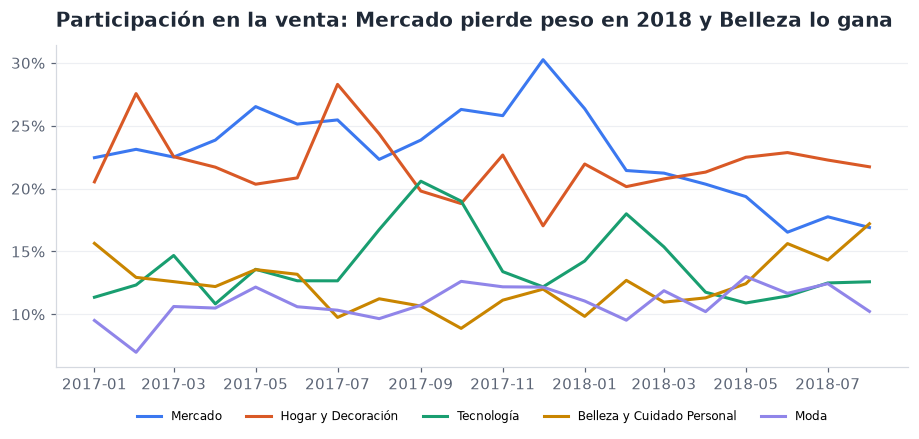

In [15]:
items["mes"] = items["order_purchase_timestamp"].dt.to_period("M")
mix = (items[items["mes"] >= "2017-01"].pivot_table(index="mes", columns="macro_category", values="price", aggfunc="sum"))
mix = mix.div(mix.sum(axis=1), axis=0)
top5 = por_macro["venta"].nlargest(5).index

fig, ax = plt.subplots(figsize=(10, 3.8))
for color, macro in zip([AZUL, NARANJA, VERDE, OCRE, VIOLETA], top5):
    ax.plot(mix.index.to_timestamp(), mix[macro], color=color, lw=2, label=macro)
ax.set_title("Participación en la venta: Mercado pierde peso en 2018 y Belleza lo gana")
fmt_pct(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=5, fontsize=8)
plt.show()

## 5. Geografía y costo de envío

SP + RJ + MG concentran el 67% de los pedidos.


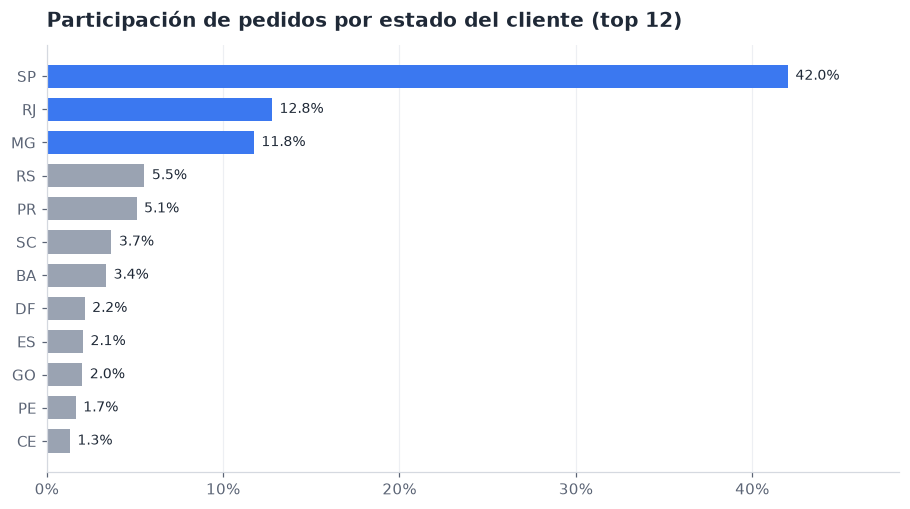

In [16]:
por_estado = pedidos.groupby("customer_state").agg(
    pedidos=("order_id", "size"), facturacion=("precio_ticket", "sum"),
    entrega_dias=("processing_time", "mean"), retraso=("late_delivery", "mean"))
por_estado["% pedidos"] = por_estado["pedidos"] / por_estado["pedidos"].sum()
top3 = por_estado["% pedidos"].nlargest(3)
print("SP + RJ + MG concentran el {:.0%} de los pedidos.".format(top3.sum()))

barras_h(por_estado["% pedidos"].nlargest(12), "Participación de pedidos por estado del cliente (top 12)", fmt="{:.1%}", resaltar=3)
fmt_pct(plt.gca(), eje="x")
plt.show()

In [17]:
envio = items.merge(pedidos[["order_id", "processing_time"]], on="order_id")
por_region = envio.groupby("customer_region").agg(
    flete_medio=("freight_value", "mean"), precio_medio=("price", "mean"))
por_region["flete / precio"] = envio.groupby("customer_region")["freight_value"].sum() / envio.groupby("customer_region")["price"].sum()
por_region["días de entrega"] = pedidos.groupby("customer_region")["processing_time"].mean()
por_region["% con retraso"] = pedidos.groupby("customer_region")["late_delivery"].mean()
por_region = por_region.sort_values("días de entrega")
tabla(por_region, {"flete_medio": "R$ {:,.1f}", "precio_medio": "R$ {:,.0f}", "flete / precio": "{:.0%}",
                         "días de entrega": "{:.1f}", "% con retraso": "{:.1%}"})

,flete_medio,precio_medio,flete / precio,días de entrega,% con retraso
customer_region,,,,,
Sudeste,R$ 17.4,R$ 114,15%,10.3,6.1%
Sur,R$ 21.3,R$ 120,18%,13.6,5.9%
Centro-Oeste,R$ 23.1,R$ 131,18%,14.6,6.6%
Nordeste,R$ 32.4,R$ 149,22%,19.5,12.7%
Norte,R$ 36.9,R$ 162,23%,22.1,8.6%


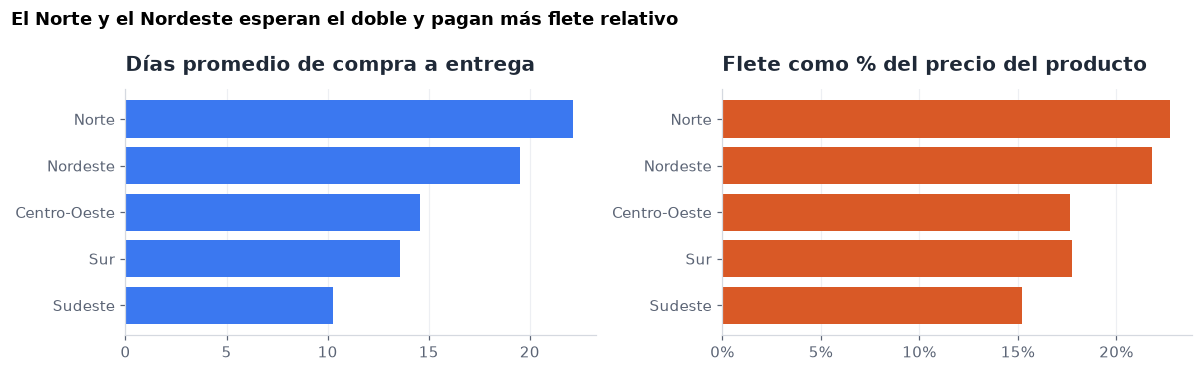

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.4))
ax1.barh(por_region.index, por_region["días de entrega"], color=AZUL)
ax1.set_title("Días promedio de compra a entrega")
ax2.barh(por_region.index, por_region["flete / precio"], color=NARANJA)
ax2.set_title("Flete como % del precio del producto")
fmt_pct(ax2, eje="x")
for ax in (ax1, ax2):
    ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
fig.suptitle("El Norte y el Nordeste esperan el doble y pagan más flete relativo", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
plt.show()

## 6. Logística: dónde se genera el retraso

Un pedido está **retrasado** si llegó después de la fecha estimada que se le informó al cliente.
Se descompone el tiempo total en tres tramos: aprobación del pago, preparación del vendedor (hasta entregar al transportista) y transporte.

In [19]:
entregados = pedidos.dropna(subset=["order_delivered_customer_date"]).copy()
entregados["tramo_aprobacion"] = (entregados["order_approved_at"] - entregados["order_purchase_timestamp"]).dt.total_seconds() / 86400
entregados["tramo_preparacion"] = (entregados["order_delivered_carrier_date"] - entregados["order_approved_at"]).dt.total_seconds() / 86400
entregados["tramo_transporte"] = (entregados["order_delivered_customer_date"] - entregados["order_delivered_carrier_date"]).dt.total_seconds() / 86400

tramos = ["tramo_aprobacion", "tramo_preparacion", "tramo_transporte"]
por_estado_entrega = entregados.groupby("late_delivery")[tramos].median().rename(index={False: "A tiempo", True: "Con retraso"})
por_estado_entrega.columns = ["Aprobación", "Preparación (vendedor)", "Transporte"]
print(f"Pedidos con retraso: {entregados['late_delivery'].mean():.1%}")
tabla(por_estado_entrega, "{:.1f} días")

Pedidos con retraso: 6.8%


,Aprobación,Preparación (vendedor),Transporte
late_delivery,,,
A tiempo,0.0 días,1.8 días,6.9 días
Con retraso,0.0 días,3.1 días,26.2 días


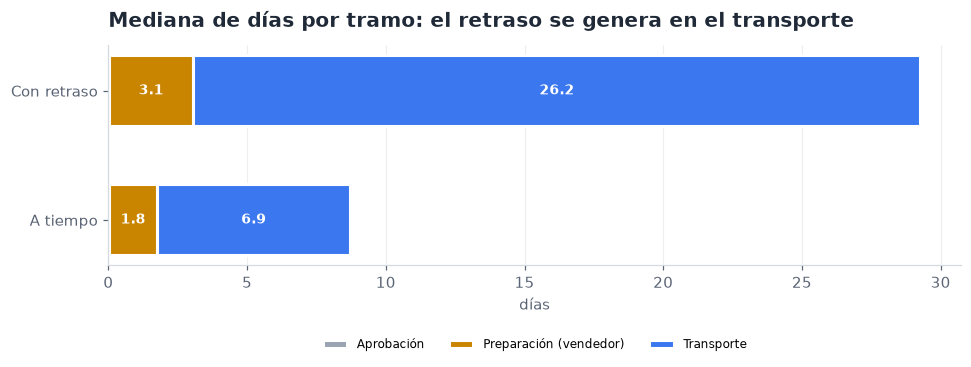

In [20]:
fig, ax = plt.subplots(figsize=(10, 2.6))
izquierda = np.zeros(2)
for color, col in zip([GRIS, OCRE, AZUL], por_estado_entrega.columns):
    v = por_estado_entrega[col].values
    ax.barh(por_estado_entrega.index, v, left=izquierda, color=color, label=col, height=0.55, edgecolor="white", linewidth=2)
    for i, (l, w) in enumerate(zip(izquierda, v)):
        if w > 1:
            ax.text(l + w / 2, i, f"{w:.1f}", ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    izquierda += v
ax.set_title("Mediana de días por tramo: el retraso se genera en el transporte")
ax.set_xlabel("días")
ax.legend(loc="upper center", ncol=3, fontsize=8, bbox_to_anchor=(0.5, -0.28))
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
plt.show()

In [21]:
# ¿El vendedor despachó tarde (después de la fecha límite) o el transportista tardó?
atrasados = df[df["late_delivery"]].drop_duplicates("order_id")
despacho_tarde = (atrasados["shipping_late_days"] > 0).mean()
print(f"De los pedidos que llegaron tarde, el {despacho_tarde:.0%} ya había sido despachado tarde por el vendedor;")
print(f"el {1 - despacho_tarde:.0%} se despachó a tiempo y el retraso ocurrió en el transporte.")

De los pedidos que llegaron tarde, el 20% ya había sido despachado tarde por el vendedor;
el 80% se despachó a tiempo y el retraso ocurrió en el transporte.


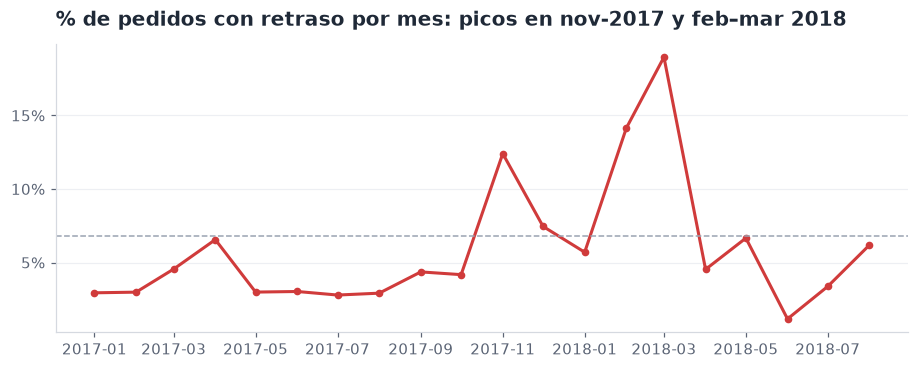

In [22]:
retraso_mes = entregados[entregados["mes"] >= "2017-01"].groupby("mes")["late_delivery"].mean()
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(retraso_mes.index.to_timestamp(), retraso_mes.values, color=MAL, lw=2, marker="o", ms=4)
ax.axhline(entregados["late_delivery"].mean(), color=GRIS, ls="--", lw=1)
ax.set_title("% de pedidos con retraso por mes: picos en nov-2017 y feb–mar 2018")
ax.yaxis.set_major_locator(plt.MultipleLocator(0.05))
fmt_pct(ax)
plt.show()

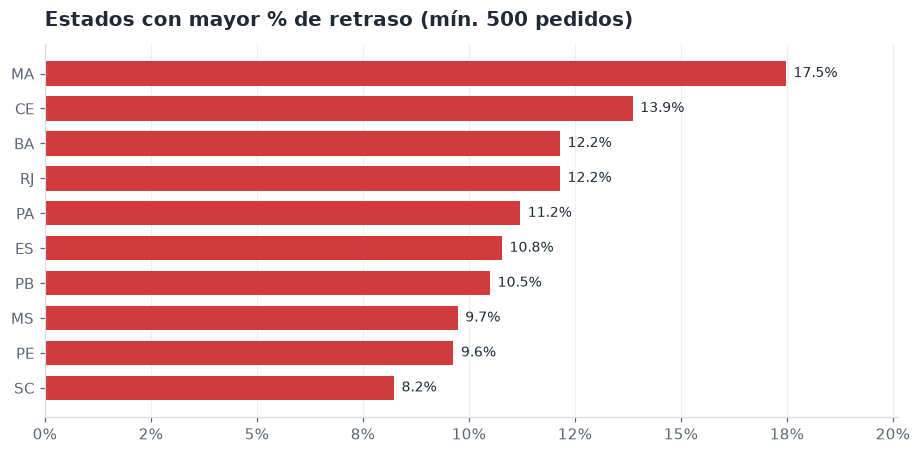

In [23]:
estados_min = por_estado[por_estado["pedidos"] >= 500]
barras_h(estados_min["retraso"].nlargest(10), "Estados con mayor % de retraso (mín. 500 pedidos)", color=MAL, fmt="{:.1%}")
fmt_pct(plt.gca(), eje="x")
plt.show()

## 7. Satisfacción: cuánto pesa el retraso

`review_score` es la calificación de 1 a 5 que deja el cliente. Se analiza a nivel de pedido (hay 645 pedidos sin reseña).

In [24]:
resenas = pedidos.dropna(subset=["review_score"])
dist = resenas["review_score"].value_counts(normalize=True).sort_index()
print(f"Puntaje medio {resenas['review_score'].mean():.2f} · {dist.loc[[4, 5]].sum():.0%} de 4–5 estrellas · {dist.loc[[1, 2]].sum():.0%} de 1–2")

por_entrega = resenas.groupby("late_delivery")["review_score"].agg(["mean", "size"]).rename(index={False: "A tiempo", True: "Con retraso"})
por_entrega["% 1–2 estrellas"] = resenas.groupby("late_delivery")["review_score"].apply(lambda s: (s <= 2).mean()).values
tabla(por_entrega, {"mean": "{:.2f}", "size": "{:,.0f}", "% 1–2 estrellas": "{:.0%}"})

Puntaje medio 4.15 · 79% de 4–5 estrellas · 13% de 1–2


,mean,size,% 1–2 estrellas
late_delivery,,,
A tiempo,4.29,"89,109",9%
Con retraso,2.27,"6,370",62%


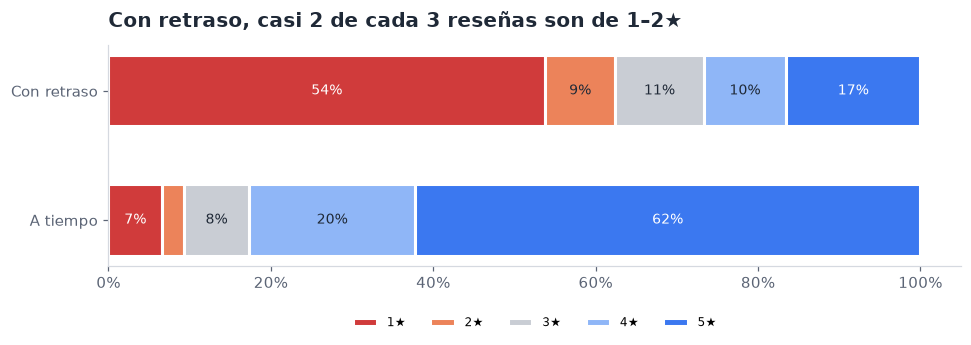

In [25]:
dist_entrega = (resenas.groupby("late_delivery")["review_score"].value_counts(normalize=True).unstack()
                .rename(index={False: "A tiempo", True: "Con retraso"}))
colores_estrellas = ["#D03B3B", "#EC835A", "#C9CDD4", "#8FB6F7", "#3B78F0"]
fig, ax = plt.subplots(figsize=(10, 2.6))
izquierda = np.zeros(len(dist_entrega))
for color, estrellas in zip(colores_estrellas, dist_entrega.columns):
    v = dist_entrega[estrellas].values
    ax.barh(dist_entrega.index, v, left=izquierda, color=color, label=f"{int(estrellas)}★", height=0.55, edgecolor="white", linewidth=2)
    for i, (l, w) in enumerate(zip(izquierda, v)):
        if w > 0.05:
            ax.text(l + w / 2, i, f"{w:.0%}", ha="center", va="center", fontsize=9,
                    color="white" if estrellas in (1, 5) else "#1F2937")
    izquierda += v
fmt_pct(ax, eje="x")
ax.legend(ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.18), fontsize=8)
ax.set_title("Con retraso, casi 2 de cada 3 reseñas son de 1–2★")
ax.grid(axis="y", visible=False)
plt.show()

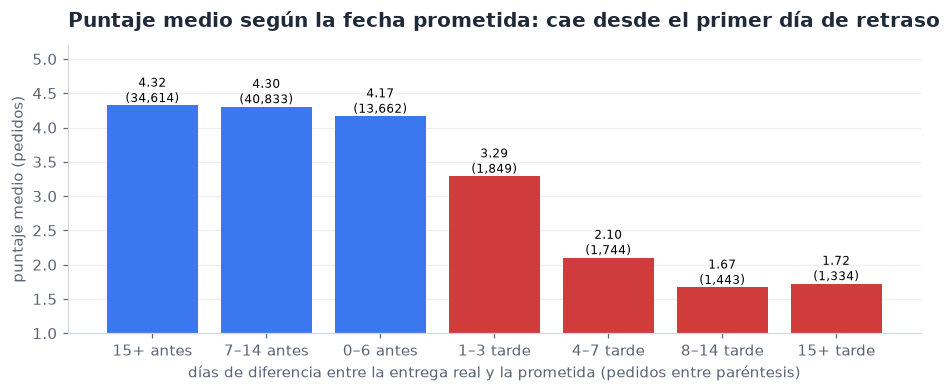

In [26]:
tramos_retraso = pd.cut(entregados["delivery_delay"], [-200, -15, -7, 0, 3, 7, 14, 400],
                        labels=["15+ antes", "7–14 antes", "0–6 antes", "1–3 tarde", "4–7 tarde", "8–14 tarde", "15+ tarde"])
curva = entregados.assign(tramo=tramos_retraso).dropna(subset=["review_score"]).groupby("tramo", observed=True).agg(
    puntaje=("review_score", "mean"), pedidos=("order_id", "size"))

fig, ax = plt.subplots(figsize=(10, 3.4))
colores = [AZUL] * 3 + [MAL] * 4
ax.bar(curva.index.astype(str), curva["puntaje"], color=colores)
for i, (p, n) in enumerate(curva.values):
    ax.text(i, p + 0.05, f"{p:.2f}\n({n:,.0f})", ha="center", fontsize=8)
ax.set_ylim(1, 5.2)
ax.set_title("Puntaje medio según la fecha prometida: cae desde el primer día de retraso")
ax.set_xlabel("días de diferencia entre la entrega real y la prometida (pedidos entre paréntesis)")
ax.set_ylabel("puntaje medio (pedidos)")
plt.show()

## 8. Clientes: recompra

`customer_unique_id` identifica a la persona (el `customer_id` original cambia en cada pedido).

In [27]:
recompra = (clientes["pedidos"] > 1).mean()
print(f"{len(clientes):,} clientes · {recompra:.1%} compró más de una vez · "
      f"{clientes.loc[clientes['pedidos'] > 1, 'gasto'].sum() / clientes['gasto'].sum():.1%} de la facturación viene de ellos")
clientes["pedidos"].clip(upper=4).value_counts().sort_index().rename(index={4: "4+"}).to_frame("clientes")

93,011 clientes · 3.0% compró más de una vez · 5.6% de la facturación viene de ellos


,clientes
pedidos,
1,90215
2,2570
3,179
4+,47


In [28]:
segundas = pedidos.sort_values("order_purchase_timestamp").groupby("customer_unique_id")["order_purchase_timestamp"].agg(["min", lambda s: s.iloc[1] if len(s) > 1 else pd.NaT])
segundas.columns = ["primera", "segunda"]
dias = (segundas["segunda"] - segundas["primera"]).dt.days.dropna()
dias = dias[dias > 0]  # misma fecha = compra dividida en dos pedidos el mismo día
print(f"Entre quienes vuelven: mediana de {dias.median():.0f} días hasta la segunda compra; el {(dias <= 90).mean():.0%} vuelve dentro de 90 días.")

Entre quienes vuelven: mediana de 76 días hasta la segunda compra; el 54% vuelve dentro de 90 días.


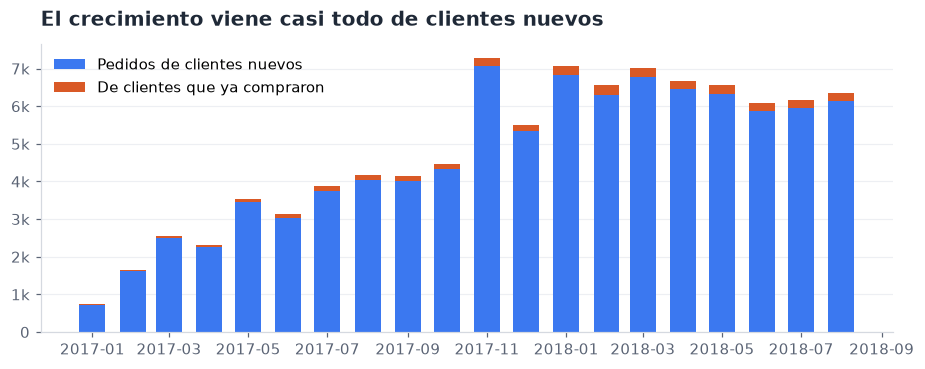

Pedidos de clientes recurrentes en 2018: 3.5%


In [29]:
pedidos_ord = pedidos.sort_values("order_purchase_timestamp")
pedidos_ord["es_nuevo"] = ~pedidos_ord.duplicated("customer_unique_id")
nuevos = pedidos_ord[pedidos_ord["mes"] >= "2017-01"].groupby("mes")["es_nuevo"].agg(["sum", "size"])
nuevos["recurrentes"] = nuevos["size"] - nuevos["sum"]

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.bar(nuevos.index.to_timestamp(), nuevos["sum"], width=20, color=AZUL, label="Pedidos de clientes nuevos")
ax.bar(nuevos.index.to_timestamp(), nuevos["recurrentes"], width=20, bottom=nuevos["sum"], color=NARANJA, label="De clientes que ya compraron")
ax.set_title("El crecimiento viene casi todo de clientes nuevos")
fmt_miles(ax)
ax.legend(loc="upper left")
plt.show()
print(f"Pedidos de clientes recurrentes en 2018: {nuevos.loc[nuevos.index.year == 2018, 'recurrentes'].sum() / nuevos.loc[nuevos.index.year == 2018, 'size'].sum():.1%}")

## 9. Vendedores

> **Nota sobre los nombres.** Olist publica los vendedores anonimizados (`seller_id` es un hash).
> Para que los gráficos sean legibles, la preparación les asigna un **seudónimo ficticio** reproducible (p. ej. *Limitless Magicians*).
> No son nombres de empresas reales.

2,970 vendedores activos · el 10% más grande (297) genera el 67% de la venta
Vendedores de SP: 60% del total y 64% de la venta


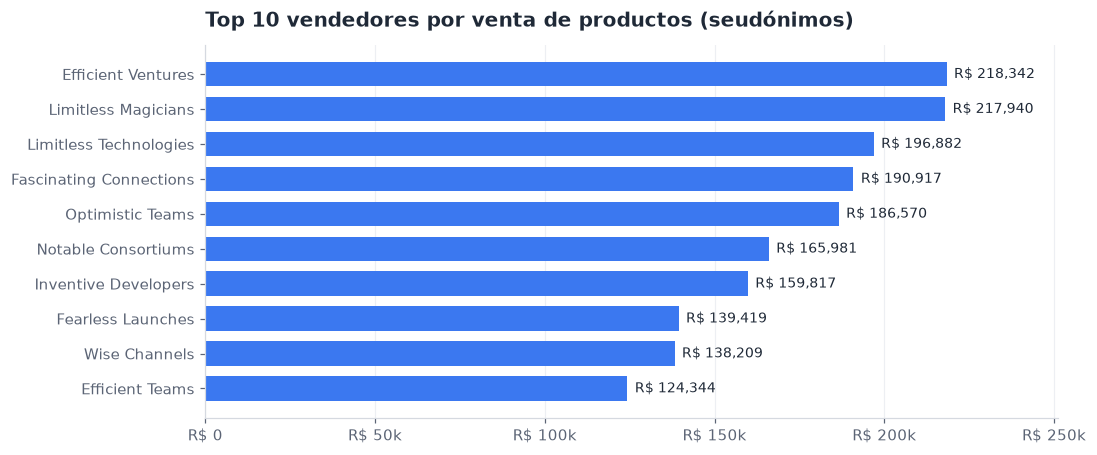

In [30]:
por_vendedor = items.groupby("seller_names").agg(venta=("price", "sum"), items=("price", "size"), pedidos=("order_id", "nunique"),
                                                   estado=("seller_state", "first")).sort_values("venta", ascending=False)
por_vendedor["% acumulado"] = por_vendedor["venta"].cumsum() / por_vendedor["venta"].sum()
top10pct = int(len(por_vendedor) * 0.1)
print(f"{len(por_vendedor):,} vendedores activos · el 10% más grande ({top10pct}) genera el {por_vendedor['% acumulado'].iloc[top10pct - 1]:.0%} de la venta")
print(f"Vendedores de SP: {(por_vendedor['estado'] == 'SP').mean():.0%} del total y {por_vendedor.loc[por_vendedor['estado'] == 'SP', 'venta'].sum() / por_vendedor['venta'].sum():.0%} de la venta")

barras_h(por_vendedor["venta"].head(10), "Top 10 vendedores por venta de productos (seudónimos)", fmt="R$ {:,.0f}")
fmt_miles(plt.gca(), eje="x", prefijo="R$ ")
plt.show()

## 10. Conclusiones

| # | Hallazgo | Evidencia | Implicancia |
|---|---|---|---|
| 1 | **El archivo plano no se puede sumar** | Sumar `payment_value` fila por fila da R$ 19,7 M; la facturación real es R$ 15,4 M (+28%) | El dashboard usa un esquema estrella con pedidos, ítems y pagos separados |
| 2 | **El crecimiento es de volumen, no de ticket** | Ene–ago 2018 vs 2017: pedidos +139%, facturación +143%, ticket medio estable en ~R$ 160 | Desde enero 2018 la facturación está plana en ~R$ 1 M/mes: la meta anual depende de volver a crecer en pedidos |
| 3 | **La venta está concentrada** | 18 de 64 categorías hacen el 80% de la venta; SP, RJ y MG el 67% de los pedidos; el 10% de los vendedores el 67% de la venta | Priorizar la gestión (surtido, logística, vendedores) en pocos frentes |
| 4 | **Pocos pedidos grandes pesan mucho** | Mediana R$ 105; los pedidos de más de R$ 350 son el 8% del volumen y el 34% de la facturación; se pagan en más cuotas | La financiación en cuotas es una palanca comercial para el ticket alto |
| 5 | **El retraso se genera en el transporte** | 6,8% de pedidos con retraso; el 80% de ellos se despachó a tiempo; en los retrasados el transporte tarda 26 días (vs. 7) | Negociar con transportistas y ajustar la fecha prometida por región pesa más que presionar a los vendedores |
| 6 | **Norte y Nordeste son el punto débil** | Esperan 20–22 días (vs. 10 en el Sudeste), pagan un flete del 22–23% del precio y el Nordeste tiene 12,7% de retrasos | Candidatos para centros logísticos regionales o transportistas alternativos |
| 7 | **Un retraso destruye la reseña** | 4,29 estrellas a tiempo vs 2,27 con retraso; con retraso, el 62% de las reseñas es de 1–2★; el puntaje cae desde el primer día tarde | La puntualidad es el principal motor de satisfacción (se modela en el notebook 03) |
| 8 | **Casi no hay recompra** | Solo el 3,0% de los clientes compró más de una vez (5,6% de la facturación); en 2018 los recurrentes son el 3,5% de los pedidos | Oportunidad clara de retención: quien vuelve lo hace en una mediana de 76 días |

**Qué se lleva al dashboard:** los hallazgos 2 y 3 alimentan las páginas *Resumen* y *Rentabilidad*; 5 y 6, la página *Operación*;
7 y 8, la página *Clientes*; y la meseta de ventas del hallazgo 2 es el punto de partida de la página *Planificación*.

**Siguiente paso:** [`03_satisfaccion_y_sentimiento.ipynb`](03_satisfaccion_y_sentimiento.ipynb) cuantifica qué factores explican una mala reseña.